# Spatial Hot Spots for Trip Demand — Gaussian Mixture Models

The notebooks `01.3` and `02_trip_patterns` analyze demand on *discrete* spatial units (census tracts, community areas, H3 hexagons). Here we take the complementary *continuous* view: we estimate a smooth demand-density surface over the city and derive hot spots from it. We use **pickup locations** as the demand signal — a pickup is where a customer requested a ride, which is exactly what a fleet operator needs to position vehicles.

**Method.** A Gaussian Mixture Model (GMM) used this way *is* a spatial kernel density estimation in parametric form. The demand density is modeled as a mixture of a small number of Gaussian kernels whose locations $\mu_k$, shapes $\Sigma_k$ and weights $\pi_k$ are learned from the data via the EM algorithm. Its decisive advantage for a fleet operator: every fitted component is an interpretable hot-spot *object* with a center, a spatial extent (covariance ellipse) and a **share of total demand**.

## 1. Imports and setup

In [1]:
# Imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from matplotlib.path import Path as MplPath
import contextily as ctx
import shapely
from scipy.spatial import cKDTree
from sklearn.mixture import GaussianMixture

# Constants
TAXI_DATA_PATH           = '../../data/chicago_taxi_2025_clean.parquet'
BOUNDARIES_DATA_PATH     = '../../data/chicago_boundaries.geojson'
COMMUNITY_AREA_DATA_PATH = '../../data/community_areas_chicago.geojson'

CRS_LATLON  = 'EPSG:4326'   # WGS84 (lat/lon)
CRS_METRIC  = 'EPSG:26916'  # UTM zone 16N — meters, correct for Chicago; distances are true meters
GRID_STEP_M = 250           # evaluation grid resolution for density surfaces
RANDOM_STATE = 42

# All density surfaces share these display settings
BASEMAP = ctx.providers.CartoDB.Positron  # light basemap so the density overlay stays readable
DENSITY_CMAP = 'viridis'
MASK_BELOW = 1.0  # hide areas with < 1 expected pickup per km² per day (visual noise floor)

## 2. Data preparation — and a caveat that drives the whole design

The Chicago data does **not** contain exact pickup points. For privacy, coordinates are **centroids**, at two different precision levels (see `00_data_loading`):

- if `pickup_census_tract` is present → coordinates = **census tract centroid** (fine, ~500 m scale),
- if the tract is masked (low trip counts) → coordinates = **community area centroid** (coarse, ~2–5 km scale).

For a density analysis, mixing both levels would be harmful: every CA-only trip collapses onto one of 77 points, creating *artificial* demand spikes in the geometric middle of large residential areas. We therefore estimate the density from **tract-precision pickups only**, and immediately check what this exclusion does to the spatial distribution (next cell). The masking removes trips from *low*-demand tracts — precisely the areas a hot-spot analysis is not about — so we expect (and verify) that high-demand areas are barely affected.

*Data vintage:* this notebook uses the **2025 extract** (`chicago_taxi_2025_clean.parquet`) — one complete calendar year — so that the partial 2026 data cannot distort per-day averages and seasonal composition. Hot-spot locations are structurally stable across years; the analysis runs unchanged on the combined 2024–2026 parquet by pointing `TAXI_DATA_PATH` at it.

In [2]:
cols = ['trip_start_timestamp', 'pickup_census_tract', 'pickup_community_area',
        'pickup_centroid_latitude', 'pickup_centroid_longitude']
trips = pd.read_parquet(TAXI_DATA_PATH, columns=cols)

# Community area geometries and names (for labeling hot spots later)
community_areas = gpd.read_file(COMMUNITY_AREA_DATA_PATH)[['area_numbe', 'community', 'geometry']]
ca_name = community_areas.assign(no=community_areas['area_numbe'].astype(int)).set_index('no')['community']

n_total = len(trips)
trips = trips.dropna(subset=['pickup_centroid_latitude', 'pickup_centroid_longitude'])
n_coords = len(trips)

# Tract-precision subset: coordinates are census-tract centroids
trips_tract = trips[trips['pickup_census_tract'].notna()]
n_tract = len(trips_tract)

n_days = trips['trip_start_timestamp'].dt.date.nunique()
print(f"Cleaned trips:                    {n_total:>9,}")
print(f"  with pickup coordinates:        {n_coords:>9,}  ({n_coords/n_total*100:.1f} %)")
print(f"  with tract-precision pickup:    {n_tract:>9,}  ({n_tract/n_total*100:.1f} %)")
print(f"Observation period: {trips['trip_start_timestamp'].min():%Y-%m-%d} to "
      f"{trips['trip_start_timestamp'].max():%Y-%m-%d}  ({n_days} days)")
print(f"Unique pickup locations (tract-precision): {trips_tract.groupby(['pickup_centroid_latitude', 'pickup_centroid_longitude']).ngroups:,}")

Cleaned trips:                    6,203,096
  with pickup coordinates:        6,094,894  (98.3 %)
  with tract-precision pickup:    2,787,940  (44.9 %)
Observation period: 2025-01-01 to 2025-12-31  (365 days)
Unique pickup locations (tract-precision): 422


In [3]:
# Representativeness check: does dropping CA-only trips distort WHERE demand sits?
# Compare each community area's share of demand: all trips with coordinates vs. tract-precision only.
share_all   = trips['pickup_community_area'].value_counts(normalize=True).rename('share_all')
share_tract = trips_tract['pickup_community_area'].value_counts(normalize=True).rename('share_tract')

shares = pd.concat([share_all, share_tract], axis=1).fillna(0.0)
corr = shares['share_all'].corr(shares['share_tract'])

top10 = shares.sort_values('share_all', ascending=False).head(10) * 100
top10.columns = ['all trips w/ coords (%)', 'tract-precision only (%)']
top10.insert(0, 'community area', [ca_name.get(int(i), '?') for i in top10.index])
print(f"Correlation of CA demand shares (all vs. tract-precision): r = {corr:.4f}\n")
print("Top 10 community areas by demand share:")
print(top10.round(2).to_string())
print("\n-> The top-5 set (downtown areas + O'Hare) is identical in both views, so the major")
print("   hot spots are not artifacts of the exclusion. The masking bias is concentrated in the")
print("   North Side residential areas (e.g., Lake View keeps only 0.7 of its 3.6 %-points):")
print("   the density surface will UNDERSTATE that corridor — we flag this in the interpretation.")

Correlation of CA demand shares (all vs. tract-precision): r = 0.9825

Top 10 community areas by demand share:
                        community area  all trips w/ coords (%)  tract-precision only (%)
pickup_community_area                                                                    
8                      NEAR NORTH SIDE                    23.36                     29.11
76                               OHARE                    20.17                     21.06
32                                LOOP                    16.72                     26.14
28                      NEAR WEST SIDE                    10.46                     13.87
33                     NEAR SOUTH SIDE                      3.6                      4.97
6                            LAKE VIEW                     3.57                      0.72
56                      GARFIELD RIDGE                     2.62                      2.65
7                         LINCOLN PARK                     2.35                

In [4]:
# The ~2.8M tract-precision pickups stack onto ~420 unique centroid locations.
# Density estimators handle this exactly via per-location weights (trip counts) —
# mathematically identical to fitting all raw points, but orders of magnitude faster.
pts = (trips_tract
       .groupby(['pickup_centroid_latitude', 'pickup_centroid_longitude'])
       .size().rename('n_trips').reset_index())

pts_gdf = gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(pts['pickup_centroid_longitude'], pts['pickup_centroid_latitude']),
    crs=CRS_LATLON,
).to_crs(CRS_METRIC)

# Keep only locations inside the city boundary
city = gpd.read_file(BOUNDARIES_DATA_PATH)
city_metric = city.to_crs(CRS_METRIC)
city_poly = city_metric.union_all()
shapely.prepare(city_poly)
xmin, ymin, xmax, ymax = city_metric.total_bounds  # shared extent for all maps

# The official city boundary extends into Lake Michigan; for display masking we
# use the city's LAND area = union of the 77 community areas
land_poly = community_areas.to_crs(CRS_METRIC).union_all()
shapely.prepare(land_poly)

inside = shapely.contains_xy(city_poly, pts_gdf.geometry.x, pts_gdf.geometry.y)
dropped = pts_gdf.loc[~inside, 'n_trips'].sum()
pts_gdf = pts_gdf[inside].copy()

XY = np.column_stack([pts_gdf.geometry.x, pts_gdf.geometry.y])
W  = pts_gdf['n_trips'].to_numpy(dtype=float)
N_USED = W.sum()

# Empirical spatial resolution floor: how far apart are neighboring tract centroids?
nn_dist, _ = cKDTree(XY).query(XY, k=2)
nn_med = np.median(nn_dist[:, 1])

print(f"Unique locations inside city: {len(pts_gdf):,}  (dropped {dropped:,.0f} trips outside boundary)")
print(f"Trips used for density estimation: {N_USED:,.0f}")
print(f"Median nearest-neighbor distance between locations: {nn_med:,.0f} m")
print("-> This is the data's spatial resolution floor; structure below this scale is not identifiable.")

Unique locations inside city: 421  (dropped 6 trips outside boundary)
Trips used for density estimation: 2,787,934
Median nearest-neighbor distance between locations: 601 m
-> This is the data's spatial resolution floor; structure below this scale is not identifiable.


## 3. Gaussian Mixture Model

We model the pickup density with a *small* number of Gaussian components,

$$\hat f(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}\!\left(x \mid \mu_k, \Sigma_k\right),$$

fitted with the EM algorithm on coordinates in a **metric CRS** (UTM 16N), so all component extents are true meters. Each component **is** a hot spot in the operational sense: $\mu_k$ is its center, the covariance $\Sigma_k$ describes its spatial extent and orientation (an ellipse — Chicago's demand areas are elongated along the lakefront, which a full covariance can capture), and the weight $\pi_k$ is its **share of total demand**. That last quantity is what makes the GMM valuable for the client: it converts a heat map into a ranked, quantified list of demand zones.

The implementation uses `sklearn.mixture.GaussianMixture` with `covariance_type='full'`, comparing candidate models by fitting one per `n_components` and plotting AIC/BIC, with a custom `draw_ellipse` helper (defined below) to visualize component extents. Three adaptations for this dataset:

1. **Sampling.** `sklearn`'s `GaussianMixture` does not accept sample weights, so we draw a large weighted sample (with replacement) from the unique locations — distributionally identical to using all 2.8M raw pickups.
2. **Regularization.** Because trips stack onto exact centroid coordinates, an unconstrained component can collapse onto a single high-mass point (O'Hare!), driving its variance to zero and the likelihood to infinity. We set `reg_covar = (100 m)²` — a variance floor stating that sub-100 m structure is not identifiable from centroid data. This is honest regularization, not a tuning trick (the measured spacing between neighboring pickup locations is ~600 m, so this floor is conservative).
3. **Choosing $K$.** A textbook approach would read the AIC/BIC minimum off the curve directly. With our sample sizes, BIC keeps improving slowly as micro-components are added, so the curve only offers an *elbow* — the $K$ after which additional components stop buying substantial improvement. We treat that elbow as an **upper bound**: below we inspect the fitted decompositions for every $K$ up to it and make the final choice on interpretability — the statistical criterion narrows the range, the spatial structure of the city makes the call.

C:\Users\Besitzer\anaconda3\envs\AA_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


BIC elbow at K = 6   (BIC minimum at K = 20)


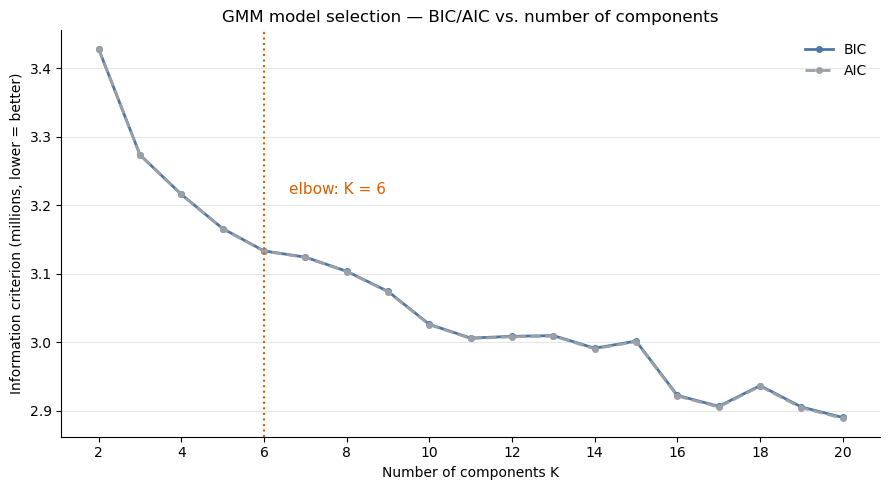

In [5]:
#| label: fig-gmm-bic
# Weighted resampling of raw pickups from the unique locations
rng = np.random.default_rng(RANDOM_STATE)
P = W / W.sum()

def sample_pickups(n):
    return XY[rng.choice(len(XY), size=n, replace=True, p=P)]

REG_COVAR = 100.0 ** 2  # variance floor: sub-100m structure is below the data's resolution

# Model selection on a 100k sample: fit one model per candidate n_components,
# then compare AIC/BIC
X_sel = sample_pickups(100_000)
n_components = np.arange(2, 21)
models = [GaussianMixture(n, covariance_type='full', reg_covar=REG_COVAR,
                          max_iter=300, random_state=RANDOM_STATE).fit(X_sel)
          for n in n_components]
bics = np.array([m.bic(X_sel) for m in models])
aics = np.array([m.aic(X_sel) for m in models])

# Elbow = point of maximum distance below the chord from first to last BIC value
b_norm = (bics - bics.min()) / (bics.max() - bics.min())
k_norm = (n_components - n_components.min()) / (n_components.max() - n_components.min())
K_ELBOW = int(n_components[np.argmax(k_norm * (b_norm[-1] - b_norm[0]) + b_norm[0] - b_norm)])
print(f"BIC elbow at K = {K_ELBOW}   (BIC minimum at K = {n_components[np.argmin(bics)]})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_components, bics / 1e6, color='#4c78a8', linewidth=2, marker='o', markersize=4, label='BIC')
ax.plot(n_components, aics / 1e6, color='#9aa0a6', linewidth=2, marker='o', markersize=4, linestyle='--', label='AIC')
ax.axvline(K_ELBOW, color='#d95f02', linewidth=1.5, linestyle=':')
ax.annotate(f'elbow: K = {K_ELBOW}', xy=(K_ELBOW, bics.min() / 1e6), xytext=(K_ELBOW + 0.6, bics[2] / 1e6),
            color='#d95f02', fontsize=11)
ax.set_xlabel('Number of components K')
ax.set_ylabel('Information criterion (millions, lower = better)')
ax.set_title('GMM model selection — BIC/AIC vs. number of components')
ax.set_xticks(n_components[::2])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

**Making the elbow visible: the decomposition from $K = 2$ to $K = 6$.** The models fitted during
selection let us watch how the mixture allocates components as $K$ grows. O'Hare is so heavy and so
isolated that it claims its own component already at $K = 2$, next to one blurred Gaussian covering
the entire downtown–lakefront corridor; $K = 3$ separates Midway, so each of the city's three
*isolated* demand poles — downtown and the two airports — has its own component; $K = 4$ and $K = 5$
begin splitting the downtown blob and introduce the wide North Side background; at the elbow $K = 6$
three downtown sub-centers, both airports and the diffuse background are all separated. Beyond that,
additional components only split existing hot spots for marginal BIC gains.

In [6]:
# Shared machinery for all maps in this notebook

# Ellipse helper: draws 1σ/2σ rings rather than the conventional 3σ — the widest
# component here spans several km, so a 3σ ring would cover half the city
def draw_ellipse(position, covariance, ax=None, n_sigmas=(1, 2), **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()

    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    # Draw the Ellipse
    for nsig in n_sigmas:
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))

def annotate_components(ax, gmm, order):
    """Component centers with demand rank; spatial extent is carried by the density
    contours (and quantified as σ values in the table)."""
    for rank, idx in enumerate(order, start=1):
        mean = gmm.means_[idx]
        ax.plot(*mean, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=5)
        ax.annotate(str(rank), xy=mean, xytext=(mean[0] + 450, mean[1] + 450),
                    color='white', fontsize=11, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='black')], zorder=6)

# All density shadings are clipped to the city's land area
def polygon_to_path(polygon):
    verts, codes = [], []
    for part in getattr(polygon, 'geoms', [polygon]):
        for ring in [part.exterior, *part.interiors]:
            v = np.asarray(ring.coords)
            verts.append(v)
            codes.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(v) - 2) + [MplPath.CLOSEPOLY])
    return MplPath(np.vstack(verts), np.array(codes))

city_clip = polygon_to_path(land_poly)

# Evaluation grid over the city (GRID_STEP_M spacing), masked to the city's land area
gx = np.arange(xmin - GRID_STEP_M, xmax + 2 * GRID_STEP_M, GRID_STEP_M)
gy = np.arange(ymin - GRID_STEP_M, ymax + 2 * GRID_STEP_M, GRID_STEP_M)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
grid_inside = shapely.contains_xy(land_poly, grid_pts[:, 0], grid_pts[:, 1])
print(f"Grid: {GX.shape[1]} x {GX.shape[0]} cells at {GRID_STEP_M} m -> {grid_inside.sum():,} inside the city")

def density_on_grid(model, n_trips):
    """Mixture density (per m²) on the evaluation grid -> expected pickups per km² per day."""
    d = np.full(len(grid_pts), np.nan)
    d[grid_inside] = np.exp(model.score_samples(grid_pts[grid_inside]))
    return d.reshape(GX.shape) * n_trips * 1e6 / n_days

def plot_density(ax, Z, title, norm, show_cbar=True):
    """Shared style for the density maps: masked log-scale surface over a light basemap,
    with labeled contour lines that make the decaying influence of each hot spot visible."""
    Zm = np.ma.masked_invalid(np.ma.masked_less(Z, MASK_BELOW))
    pcm = ax.pcolormesh(GX, GY, Zm, cmap=DENSITY_CMAP, norm=norm, alpha=0.8, shading='auto', zorder=2)
    cs = ax.contour(GX, GY, np.where(np.isnan(Z), 0.0, Z), levels=[10, 100, 1000],
                    colors='white', linewidths=0.8, alpha=0.9, zorder=3)
    ax.clabel(cs, fmt=lambda v: f'{v:g}', fontsize=8)
    city_metric.boundary.plot(ax=ax, color='#333333', linewidth=1.0, zorder=3)
    ax.set_xlim(xmin - 1000, xmax + 1000)
    ax.set_ylim(ymin - 1000, ymax + 1000)
    ctx.add_basemap(ax, crs=CRS_METRIC, source=BASEMAP, zorder=0, attribution_size=5)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()
    if show_cbar:
        cbar = plt.colorbar(pcm, ax=ax, shrink=0.7, pad=0.01)
        cbar.set_label('Expected pickups per km² per day (log scale)')
    return pcm

Grid: 141 x 172 cells at 250 m -> 9,539 inside the city


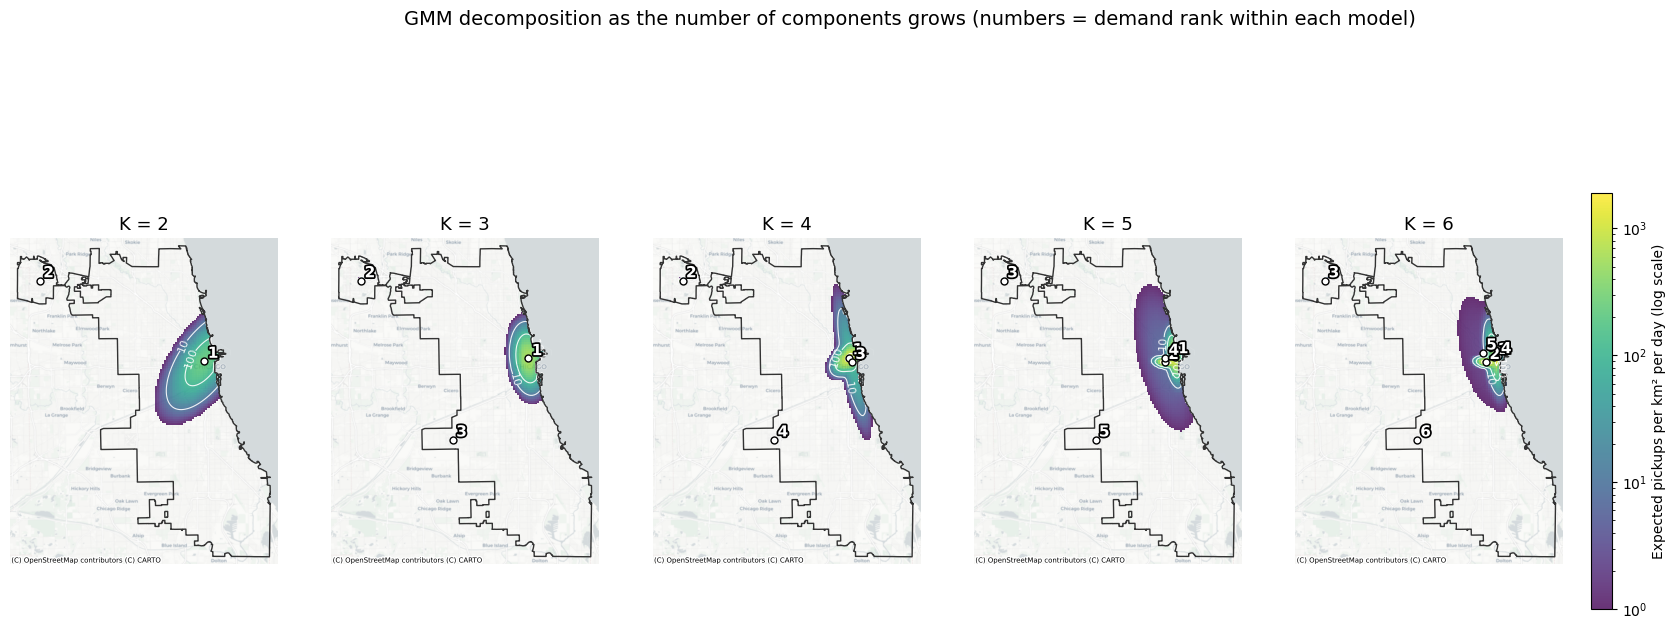

In [7]:
#| label: fig-gmm-k-comparison
# Same weighted sample as the model selection — one panel per K up to the elbow
ks_show = list(range(2, K_ELBOW + 1))
Zks = {k: density_on_grid(models[k - int(n_components[0])], N_USED)   # models[i] was fitted with n_components[i]
       for k in ks_show}

# One log color scale shared by ALL density maps in this notebook
DENSITY_NORM = LogNorm(vmin=MASK_BELOW, vmax=np.nanquantile(Zks[K_ELBOW], 0.999))

fig, axes = plt.subplots(1, len(ks_show), figsize=(24, 9))
for ax, k in zip(axes, ks_show):
    m = models[k - int(n_components[0])]
    pcm = plot_density(ax, Zks[k], f'K = {k}', DENSITY_NORM, show_cbar=False)
    annotate_components(ax, m, np.argsort(m.weights_)[::-1])
# One shared colorbar keeps all five panels the same size
cbar = fig.colorbar(pcm, ax=list(axes), shrink=0.6, pad=0.015)
cbar.set_label('Expected pickups per km² per day (log scale)')
fig.suptitle('GMM decomposition as the number of components grows (numbers = demand rank within each model)',
             fontsize=14, y=0.93)
plt.show()

## 4. Choosing the final model: $K = 3$, not the elbow $K = 6$

The BIC elbow points at $K = 6$ — but an information criterion only measures *statistical fit*, not usefulness, and the decomposition panels above show what the extra components actually buy. From $K = 3$ onward, no genuinely new *place* appears: every additional component either subdivides the interior of the downtown blob or adds diffuse background. $K = 3$ is the model in which each component corresponds to exactly one of the city's **three physically distinct demand poles**:

- the **city center** — the contiguous downtown–lakefront corridor (River North/Streeterville, the Loop, the rail-station district),
- **O'Hare International Airport** in the far northwest, and
- **Midway International Airport** on the southwest side.

These three are separated by kilometers of low-demand city, so they are unambiguous, spatially disjoint hot spots. The downtown sub-centers that $K \geq 4$ starts to separate lie only a few hundred meters apart — at the edge of the ~600 m resolution floor of the centroid data — and are operationally *one* contiguous staging area, not zones a driver would be dispatched to separately. Three zones also map one-to-one onto distinct operating regimes for a fleet (city-center cruising vs. airport queueing), which makes the model directly communicable to the client.

We therefore fix **$K = 3$** for the final hot-spot model, a deliberate and documented deviation from the raw statistical criterion: interpretability and the data's resolution floor outweigh a marginal BIC gain. The $K = 6$ decomposition above remains available as a fine-structure reading of the downtown core.

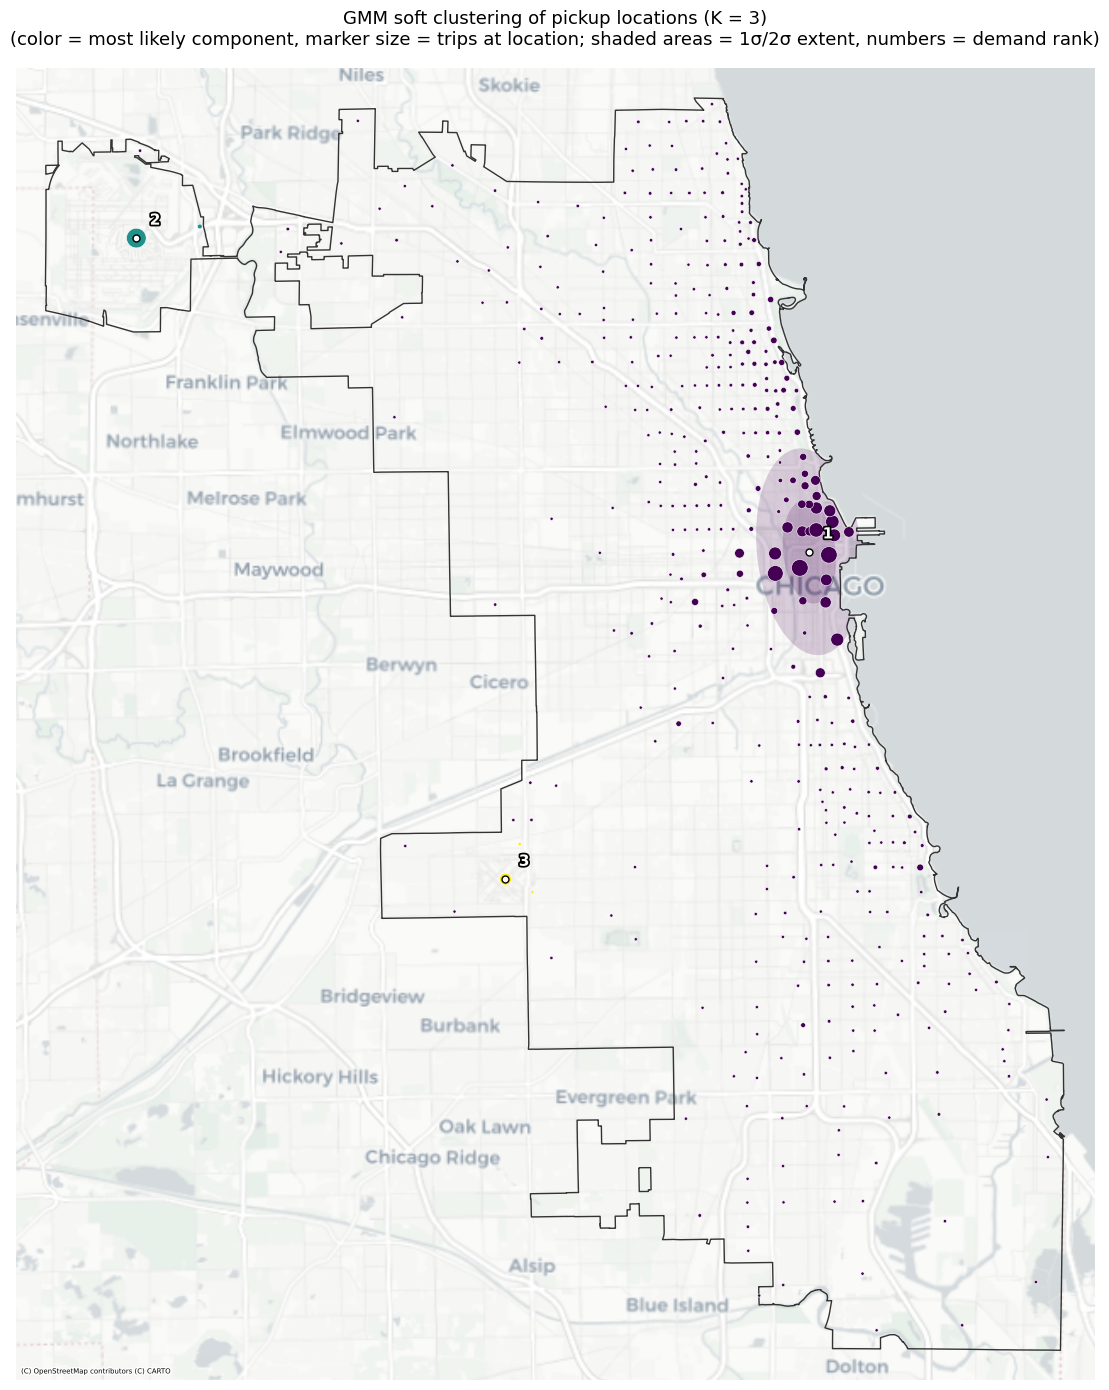

In [8]:
#| label: fig-gmm-clusters
K_FINAL = 3  # chosen on interpretability (see above); the elbow K = 6 stays as fine-structure view

# Final model on a larger sample, more restarts for stability
X_fit = sample_pickups(400_000)
gmm = GaussianMixture(n_components=K_FINAL, covariance_type='full', reg_covar=REG_COVAR,
                      max_iter=500, n_init=3, random_state=RANDOM_STATE).fit(X_fit)
order = np.argsort(gmm.weights_)[::-1]  # components ranked by demand share

# GMM soft-clustering view: each pickup location colored by its most likely component
# (gmm.predict; soft memberships would be gmm.predict_proba). Component extents are drawn
# as shaded 1σ/2σ regions in the component's color — the overlap makes the core darker.
fig, ax = plt.subplots(figsize=(12, 14))
labels = gmm.predict(XY)
cmap = plt.get_cmap(DENSITY_CMAP)
ax.scatter(XY[:, 0], XY[:, 1], c=labels, cmap=DENSITY_CMAP, vmin=0, vmax=K_FINAL - 1, zorder=3,
           s=5 + 195 * np.sqrt(W / W.max()),  # marker size ~ trips at that location
           edgecolors='white', linewidths=0.4)
for rank, idx in enumerate(order, start=1):
    mean = gmm.means_[idx]
    draw_ellipse(mean, gmm.covariances_[idx], ax=ax, zorder=2,
                 facecolor=cmap(idx / (K_FINAL - 1)), edgecolor='none', alpha=0.18,
                 clip_path=(city_clip, ax.transData))
    ax.plot(*mean, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=5)
    ax.annotate(str(rank), xy=mean, xytext=(mean[0] + 450, mean[1] + 450),
                color='white', fontsize=11, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')], zorder=6)
city_metric.boundary.plot(ax=ax, color='#333333', linewidth=1.0, zorder=1)
ax.set_xlim(xmin - 1000, xmax + 1000)
ax.set_ylim(ymin - 1000, ymax + 1000)
ctx.add_basemap(ax, crs=CRS_METRIC, source=BASEMAP, zorder=0, attribution_size=5)
ax.set_title(f'GMM soft clustering of pickup locations (K = {K_FINAL})\n'
             '(color = most likely component, marker size = trips at location; shaded areas = 1σ/2σ extent, numbers = demand rank)',
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

The cluster view above shows *which* component each location belongs to. To read the model as a demand *map*, we evaluate the mixture density on a regular 250 m grid over the city and convert it into an interpretable unit: **expected pickups per km² per day**.

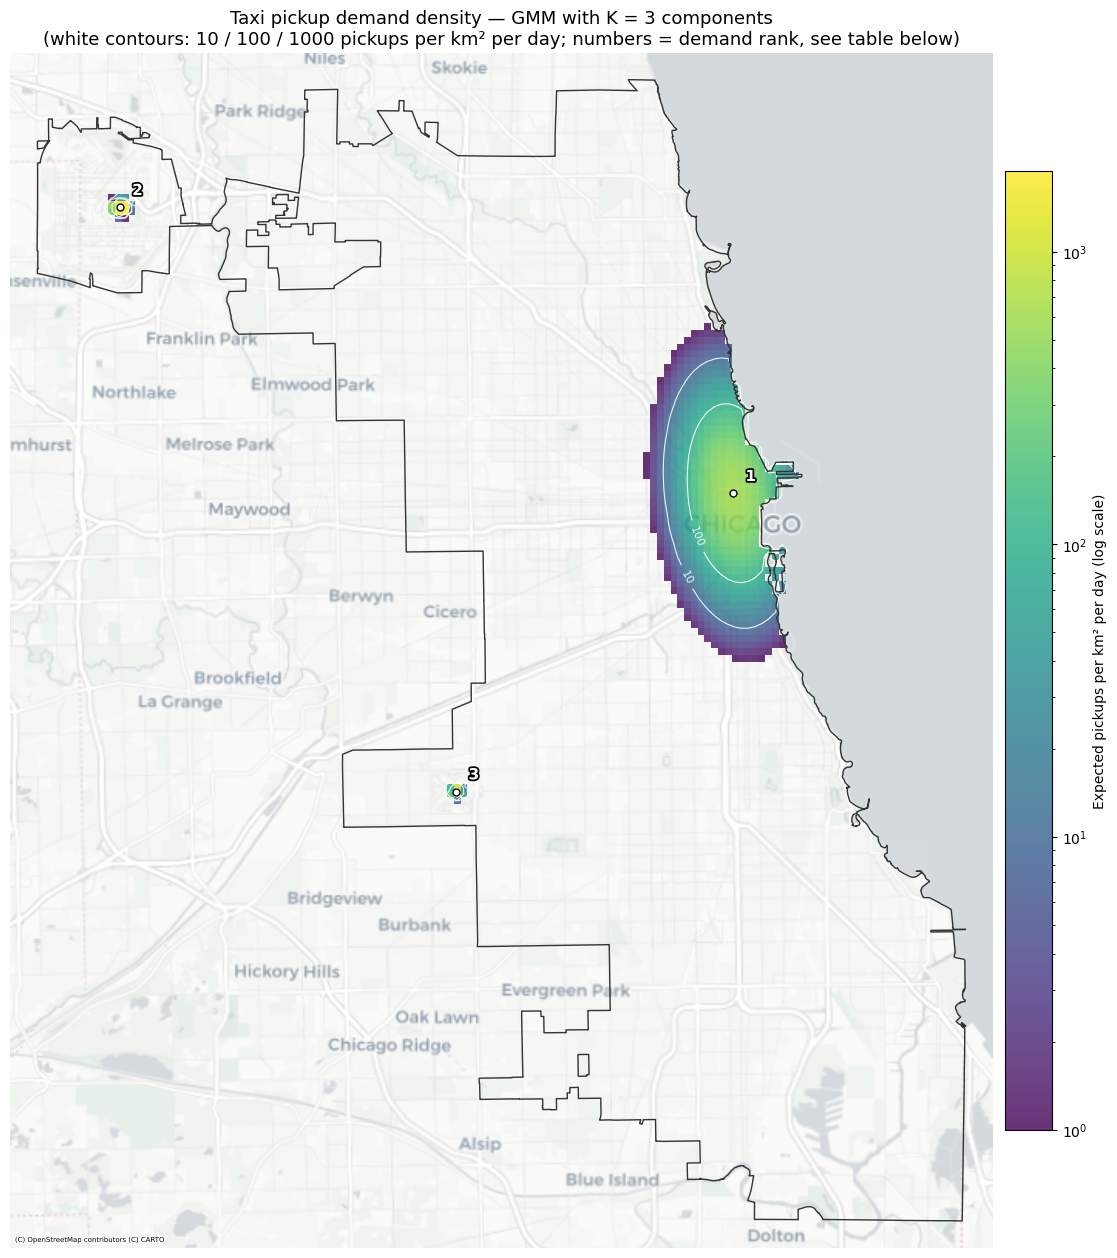

In [9]:
#| label: fig-gmm-hotspots
#| fig-cap: "Fitted GMM demand density over the city, in expected pickups per km² per day (log scale). Numbered markers are the three components' centers, ranked by demand share; white contours mark the 10 / 100 / 1000 pickups per km² per day levels."
Z_gmm = density_on_grid(gmm, N_USED)

fig, ax = plt.subplots(figsize=(12, 14))
plot_density(ax, Z_gmm, f'Taxi pickup demand density — GMM with K = {K_FINAL} components\n'
                        '(white contours: 10 / 100 / 1000 pickups per km² per day; numbers = demand rank, see table below)', DENSITY_NORM)
annotate_components(ax, gmm, order)
plt.tight_layout()
plt.show()

In [10]:
#| label: tbl-gmm-hotspots
# Ranked hot-spot table: each GMM component as an operational demand zone
centers = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gmm.means_[order, 0], gmm.means_[order, 1]),
                           crs=CRS_METRIC)
centers = gpd.sjoin(centers, community_areas.to_crs(CRS_METRIC), how='left', predicate='within')
centers = centers[~centers.index.duplicated(keep='first')]
centers_ll = centers.to_crs(CRS_LATLON)

rows = []
for rank, idx in enumerate(order, start=1):
    vals = np.linalg.eigvalsh(gmm.covariances_[idx])
    rows.append({
        'rank': rank,
        'community area': centers['community'].iloc[rank - 1],
        'lat': round(centers_ll.geometry.y.iloc[rank - 1], 4),
        'lon': round(centers_ll.geometry.x.iloc[rank - 1], 4),
        'demand share (%)': round(gmm.weights_[idx] * 100, 1),
        'pickups/day': int(round(gmm.weights_[idx] * N_USED / n_days)),
        'extent σ-major (m)': int(round(np.sqrt(vals[1]))),
        'extent σ-minor (m)': int(round(np.sqrt(vals[0]))),
    })
gmm_hotspots = pd.DataFrame(rows).set_index('rank')
print(f"GMM hot spots (K = {K_FINAL}, ranked by demand share; "
      f"pickups/day refers to tract-resolved demand):")
print(gmm_hotspots.to_string())

GMM hot spots (K = 3, ranked by demand share; pickups/day refers to tract-resolved demand):
      community area      lat      lon  demand share (%)  pickups/day  extent σ-major (m)  extent σ-minor (m)
rank                                                                                                         
1               LOOP  41.8859 -87.6290              76.3         5830                1746                 878
2              OHARE  41.9791 -87.9030              21.0         1607                 123                 100
3     GARFIELD RIDGE  41.7860 -87.7509               2.6          201                 101                 100


**Reading the hot-spot map.** Demand is extremely concentrated — the log color scale spans three orders of magnitude — and the three components decompose it exactly along the city's demand poles:

- The **city-center component** carries **76 %** of all pickups (~5,800 tract-resolved pickups per day). Its ellipse is elongated along the lakefront (σ ≈ 1.7 km × 0.9 km, table above) — the full covariance captures the orientation of demand along the Michigan Ave/State St corridor. It also absorbs the North Side residential corridor (Lakeview/Lincoln Park), which the surface *understates*: privacy masking hits those areas hardest (representativeness check above).
- The **airports** get tight, heavy components: O'Hare alone carries **21 %** of all pickups, Midway **~3 %** (its center falls in the Garfield Ridge community area, which contains the airport) — sharp, isolated peaks decoupled from their surrounding neighborhoods and driven by flight schedules. Both sit essentially at the 100 m variance floor: their demand is a point mass at the terminals, precisely the degeneracy the `reg_covar` regularization anticipated.
- The **West and South Sides** sit two to three orders of magnitude below downtown — consistent with the community-area choropleths in `01.3`.

Each hot spot carries a demand share, an expected daily pickup volume and a spatial footprint (table above) — the parametric summary a fleet operator can plan with directly.

## 5. Are the hot spots stable over the day?

Fleet positioning is a temporal decision, so we check whether the *spatial* hot spots move between **daytime (07–19)** and **nighttime (19–07)**. We refit the GMM (same $K = 3$, same settings) on each subset. Numbers on the maps are demand ranks *within each period*; the lists below the figure name them.

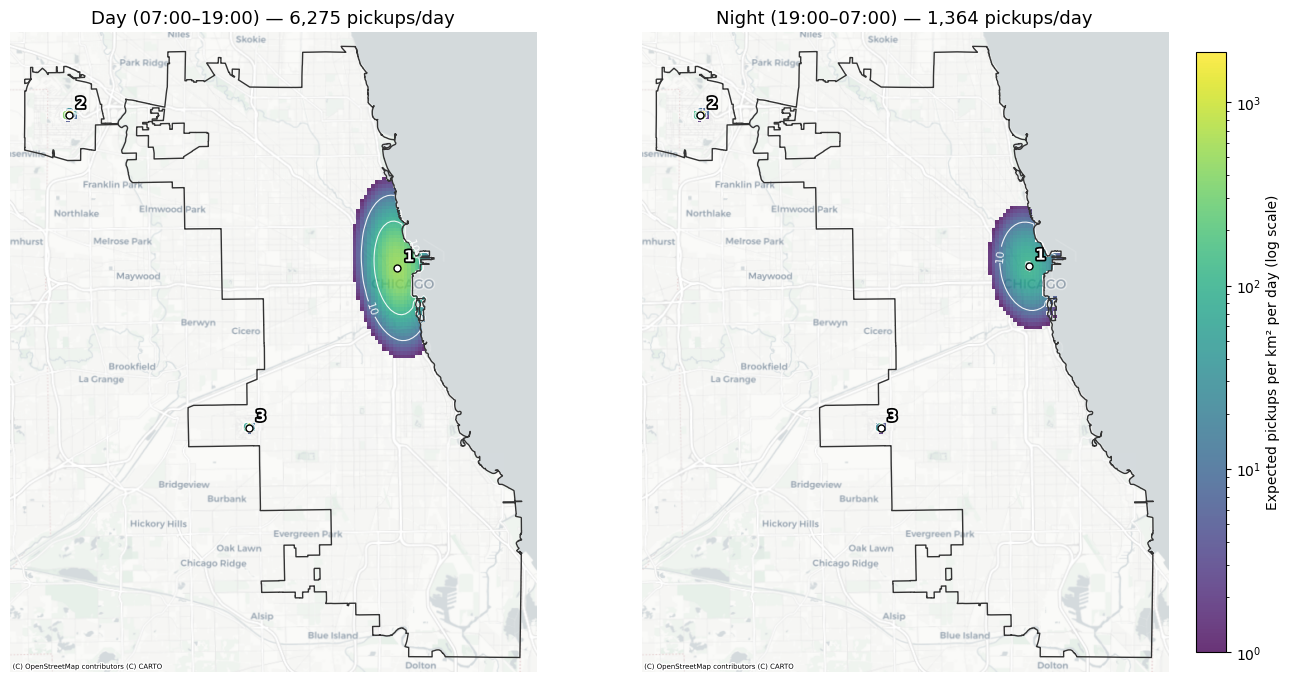

Day (07:00–19:00): LOOP (80 %), OHARE (18 %), GARFIELD RIDGE (2 %)
Night (19:00–07:00): LOOP (61 %), OHARE (36 %), GARFIELD RIDGE (4 %)


In [11]:
#| label: fig-hotspots-day-night
#| fig-cap: "Three-component GMM hot spots fitted separately for daytime (07:00–19:00) and nighttime (19:00–07:00). Percentages show each component's share of tract-resolved pickup demand within the respective period."

hour = trips_tract['trip_start_timestamp'].dt.hour
subsets = {'Day (07:00–19:00)': trips_tract[(hour >= 7) & (hour < 19)],
           'Night (19:00–07:00)': trips_tract[(hour < 7) | (hour >= 19)]}

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
tod_results = {}
for ax, (label, sub) in zip(axes, subsets.items()):
    p = (sub.groupby(['pickup_centroid_latitude', 'pickup_centroid_longitude'])
            .size().rename('n_trips').reset_index())
    g = gpd.GeoDataFrame(p, geometry=gpd.points_from_xy(p['pickup_centroid_longitude'],
                                                        p['pickup_centroid_latitude']),
                         crs=CRS_LATLON).to_crs(CRS_METRIC)
    g = g[shapely.contains_xy(city_poly, g.geometry.x, g.geometry.y)]
    xy, w = np.column_stack([g.geometry.x, g.geometry.y]), g['n_trips'].to_numpy(float)
    X_tod = xy[rng.choice(len(xy), size=200_000, replace=True, p=w / w.sum())]
    gmm_tod = GaussianMixture(n_components=K_FINAL, covariance_type='full', reg_covar=REG_COVAR,
                              max_iter=500, n_init=2, random_state=RANDOM_STATE).fit(X_tod)
    order_tod = np.argsort(gmm_tod.weights_)[::-1]
    tod_results[label] = (gmm_tod, order_tod, w.sum())

    Z_tod = density_on_grid(gmm_tod, w.sum())
    pcm = plot_density(ax, Z_tod, f'{label} — {w.sum() / n_days:,.0f} pickups/day', DENSITY_NORM,
                       show_cbar=False)
    annotate_components(ax, gmm_tod, order_tod)
# One shared colorbar keeps both panels the same size
cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), shrink=0.65, pad=0.02)
cbar.set_label('Expected pickups per km² per day (log scale)')
plt.show()

# Where do the components sit in each period?
for label, (gmm_tod, order_tod, _) in tod_results.items():
    c = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gmm_tod.means_[order_tod, 0],
                                                     gmm_tod.means_[order_tod, 1]), crs=CRS_METRIC)
    c = gpd.sjoin(c, community_areas.to_crs(CRS_METRIC), how='left', predicate='within')
    c = c[~c.index.duplicated(keep='first')]
    tops = ', '.join(f"{name} ({gmm_tod.weights_[idx] * 100:.0f} %)"
                     for name, idx in zip(c['community'], order_tod))
    print(f"{label}: {tops}")

## 6. Findings & implications for the client

**Yes — trip demand has clearly identifiable spatial hot spots: a three-component Gaussian mixture describes the demand surface with one operational zone per demand pole — the city center and the two airports.**

1. **Demand is extremely concentrated.** Three Gaussian components cover the entire market: **76 %** of all pickups originate in the extended city center (River North/Streeterville, the station district, the Loop), **21 %** at O'Hare and **~3 %** at Midway. A fleet operator does not need city-wide coverage to start — three staging areas serve essentially the whole market.
2. **Hot spots are structural, not random.** They coincide with employment density (Loop), transport infrastructure (airport terminals, Union/Ogilvie stations) and nightlife/tourism (River North, Magnificent Mile). These generators are stable, so the hot spots are a sound basis for infrastructure decisions — e.g., siting charging capacity inside or adjacent to the top demand ellipses.
3. **Day vs. night shifts the mix, not the map.** Refitting the same three-component model on day and night subsets leaves the zones in place but changes their weights: by day the city center dominates (80 % vs. O'Hare's 18 %); at night O'Hare's share **doubles to 36 %** (late arrivals meet a thinner city market) while the city center falls to 61 % — and absolute volumes drop (per-panel pickup counts in the figure titles). Vehicle *rebalancing* between the same three zones — CBD-heavy by day, airport-heavier in the evening — is the operational lever.
4. **Method guidance.** Used as a spatial density estimator, the GMM delivers both the demand map itself (the mixture density, in pickups per km² per day) and a compact, quantified zone model (share, volume, footprint per hot spot). Model selection combined the BIC elbow (an upper bound of $K = 6$) with interpretability (final $K = 3$): the extra components only subdivide the contiguous downtown area near the data's resolution floor, so the smaller model is the one to plan with — and the $K$-comparison panels document that trade-off transparently.

**Limitations.** (i) Coordinates are tract centroids — nothing below ~600 m is identifiable, and the analysis inherits Chicago's privacy masking (low-demand tracts underrepresented; we verified rankings are unaffected). (ii) Taxi trips proxy ride-hailing demand; airport queues and medallion regulations may overstate airport hot spots relative to app-based services. (iii) Densities describe *observed, served* demand — latent demand in underserved areas is invisible by construction. (iv) With $K = 3$ the city-center component averages over downtown sub-centers a few hundred meters apart; the $K = 6$ view above provides that fine structure where needed.